In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
df = pd.read_csv('antenas.csv')
df

,antena,descarga
0,1,70
1,2,120
2,3,140
3,4,190
4,5,70
5,1,70
6,2,170
7,3,180
8,4,250
9,5,100


Text(5.069444444444445, 0.5, 'Descarga (Mbps)')

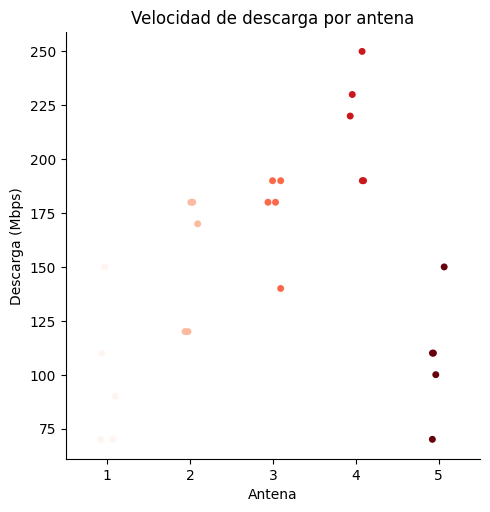

In [25]:
sns.catplot(x='antena',y='descarga',hue='antena',data=df,palette='Reds',legend=False)
plt.title('Velocidad de descarga por antena')
plt.xlabel('Antena')
plt.ylabel('Descarga (Mbps)')

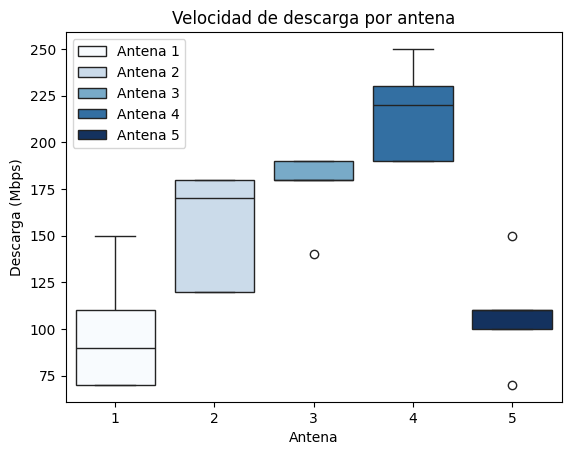

In [26]:
sns.boxplot(x='antena',y='descarga',hue='antena',data=df,palette='Blues',orient = 'v')
plt.title('Velocidad de descarga por antena')
plt.xlabel('Antena')
plt.ylabel('Descarga (Mbps)')
plt.legend(title='',labels=['Antena 1','Antena 2','Antena 3','Antena 4','Antena 5'])


In [27]:
import scipy.stats as stats
f_statistic, p_value = stats.f_oneway(df.descarga[df.antena==1],df.descarga[df.antena==2],df.descarga[df.antena==3],df.descarga[df.antena==4],df.descarga[df.antena==5])
print("Estadístico F:", f_statistic)
print("Valor p:", p_value)
alpha = 0.05
if p_value < alpha:
    print("Rechazamos la hipótesis nula: Existe al menos una diferencia significativa entre las velocidades de descarga.")
else:
    print("No rechazamos la hipótesis nula: No hay evidencia suficiente para concluir que existe una diferencia significativa entre las velocidades de descarga.")

Estadístico F: 14.756823821339944
Valor p: 9.127937124058487e-06
Rechazamos la hipótesis nula: Existe al menos una diferencia significativa entre las velocidades de descarga.


In [28]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

model = ols('descarga ~ C(antena)', data=df).fit()
aov_table = sm.stats.anova_lm(model, typ=2)

aov_table

,sum_sq,df,F,PR(>F)
C(antena),47576.0,4.0,14.756824,0.000009
Residual,16120.0,20.0,NaN,NaN


In [29]:
import statsmodels.stats.multicomp as mc

tukey = mc.pairwise_tukeyhsd(df.descarga, df.antena, alpha=0.05)
print(tukey)

  Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1 group2 meandiff p-adj    lower    upper   reject
-------------------------------------------------------
     1      2     56.0 0.0385    2.2704 109.7296   True
     1      3     78.0 0.0026   24.2704 131.7296   True
     1      4    118.0    0.0   64.2704 171.7296   True
     1      5     10.0 0.9798  -43.7296  63.7296  False
     2      3     22.0 0.7372  -31.7296  75.7296  False
     2      4     62.0 0.0189    8.2704 115.7296   True
     2      5    -46.0 0.1163  -99.7296   7.7296  False
     3      4     40.0 0.2101  -13.7296  93.7296  False
     3      5    -68.0 0.0091 -121.7296 -14.2704   True
     4      5   -108.0 0.0001 -161.7296 -54.2704   True
-------------------------------------------------------


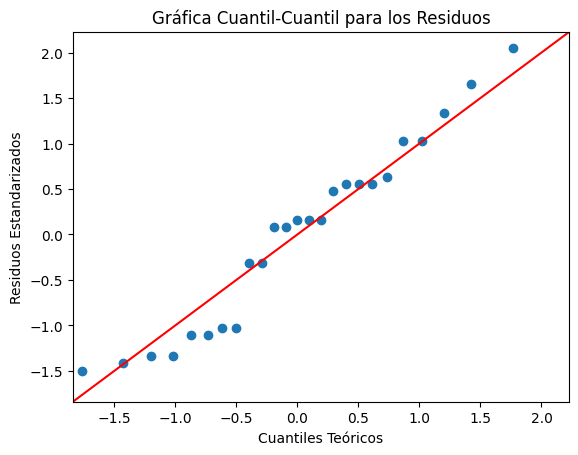

In [30]:
res = model.resid
sm.qqplot(res,fit=True ,line='45')
plt.title('Gráfica Cuantil-Cuantil para los Residuos')
plt.xlabel("Cuantiles Teóricos")
plt.ylabel("Residuos Estandarizados")
plt.show()

Text(0.5, 1.0, 'Residuos vs. Valores Ajustados')

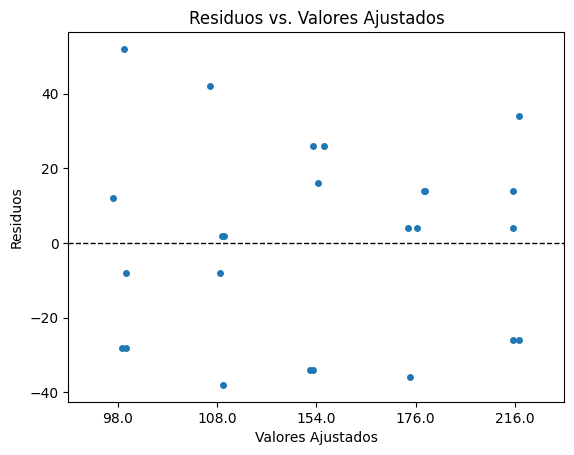

In [31]:
adj = model.fittedvalues.round(2)
sns.stripplot(x=adj,y=res)
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.ylabel('Residuos')
plt.xlabel('Valores Ajustados')
plt.title('Residuos vs. Valores Ajustados')

Text(0, 0.5, 'Residuos')

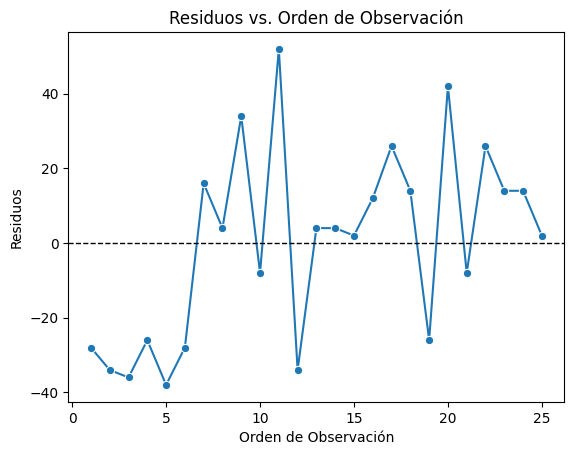

In [32]:
sns.lineplot(x=res.index+1,y=res,marker='o')
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.title('Residuos vs. Orden de Observación')
plt.xlabel('Orden de Observación')
plt.ylabel('Residuos')

Text(0.5, 0.98, 'Verificación de Supuestos del Modelo ANOVA')

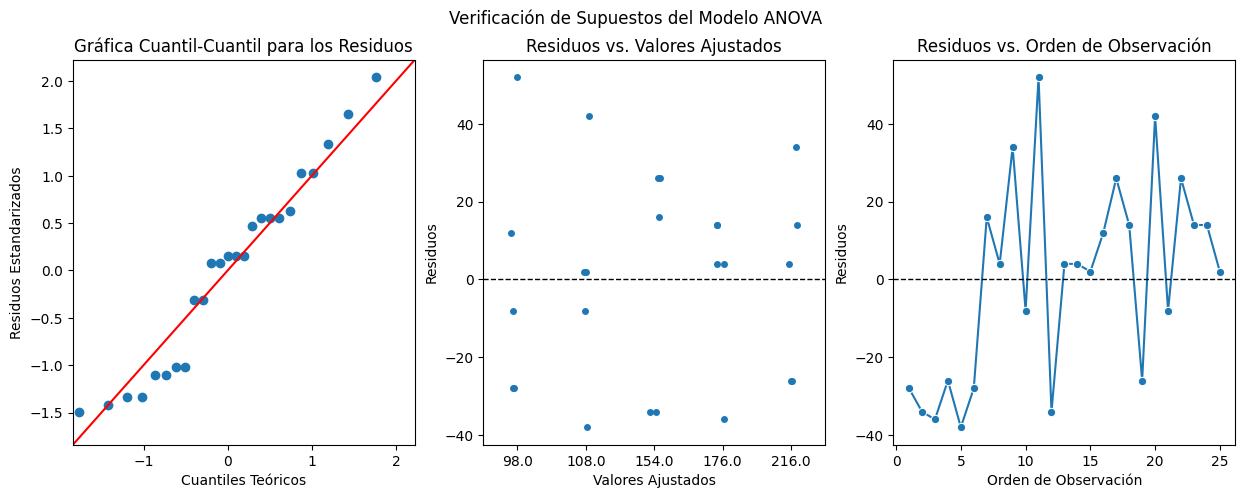

In [33]:
# Verificación de Supuestos

fig, axs = plt.subplots(ncols=3,figsize=(15,5))

res = model.resid
sm.qqplot(res,fit=True ,line='45',ax=axs[0])
axs[0].set_title('Gráfica Cuantil-Cuantil para los Residuos')
axs[0].set_xlabel("Cuantiles Teóricos")
axs[0].set_ylabel("Residuos Estandarizados")



adj = model.fittedvalues.round(2)
sns.stripplot(x=adj,y=res,ax=axs[1])
axs[1].axhline(y=0, color='black', linestyle='--', linewidth=1)
axs[1].set_ylabel('Residuos')
axs[1].set_xlabel('Valores Ajustados')
axs[1].set_title('Residuos vs. Valores Ajustados')


sns.lineplot(x=res.index+1,y=res,marker='o',ax=axs[2])
axs[2].axhline(y=0, color='black', linestyle='--', linewidth=1)
axs[2].set_title('Residuos vs. Orden de Observación')
axs[2].set_xlabel('Orden de Observación')
axs[2].set_ylabel('Residuos')

fig.suptitle('Verificación de Supuestos del Modelo ANOVA')
